Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Entrenando Red Neuronal ---
Precisión (Accuracy) del modelo Red Neuronal: 0.9997


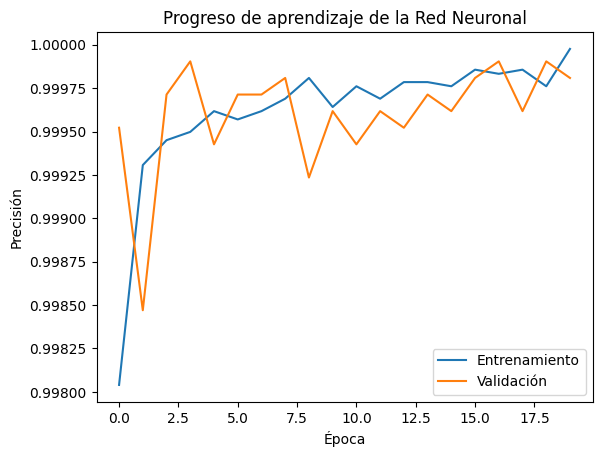

In [1]:
# --- Dependencias necesarias ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Montaje de Drive y Carga de datos
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/data/Rice_MSC_Dataset.csv')

# 2. Función de limpieza (basada en tu lógica original)
def limpiar_lote(df):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mean())
    return df.drop_duplicates()

df = limpiar_lote(df)

# 3. Ingeniería de Variable Objetivo (Target Binario)
df['Calidad_Aceptable'] = np.where(df['CLASS'] == 'Basmati', 1, 0)
X = df.drop(columns=['CLASS', 'Calidad_Aceptable'])
y = df['Calidad_Aceptable']

# 4. Preparación de datos para la Red Neuronal
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Escalamos las características para la Red Neuronal

# División de datos
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)

# 5. Construcción de la Red Neuronal (Keras)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Entrenamiento
print("\n--- Entrenando Red Neuronal ---")
history = model.fit(X_train_s, y_train_s, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

# 7. Evaluación
loss, acc_nn = model.evaluate(X_test_s, y_test_s, verbose=0)
print(f"Precisión (Accuracy) del modelo Red Neuronal: {acc_nn:.4f}")

# Visualización
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Progreso de aprendizaje de la Red Neuronal')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()
